# Lecture 12d — Logistic Regression: Hyperparameters (Optional)

> *Optional / Career-track* — read **after** the mandatory `lec_12a`, `lec_12b`, `lec_12c`. Skipping this notebook will not affect your grade. It exists for students who want to know what each `LogisticRegression` constructor argument actually does.

`sklearn.linear_model.LogisticRegression` exposes roughly nine knobs. Most are not load-bearing on small problems, but each one has a job. This notebook varies them **one at a time** on a fixed train/test split — the simplest possible way to see what each does.

**Why one-at-a-time, not a grid?** Grid search and `GridSearchCV` are the topic of Lecture 13. Here we trade thoroughness for clarity: students see the *shape* of each parameter's effect, not a tuned-from-the-clouds best score.

## Lecture map

- **§A** Imports and shared data (iris + a binary synthetic).
- **§B** Constructor signature overview — the nine knobs at a glance.
- **§C** `C` — inverse regularization strength.
- **§D** `penalty` (now via `l1_ratio`) — L1 / L2 / elasticnet / none.
- **§E** `solver` — and the solver / penalty compatibility table.
- **§F** `class_weight` — `None` vs `'balanced'` on imbalanced data.
- **§G** `multi_class` — OVR (wrapper) vs the default multinomial fit on iris.
- **§H** `max_iter` and `ConvergenceWarning`.
- **§I** `fit_intercept=False` — the no-intercept aside.
- **§J** Recap and forward pointer to Lecture 13.

> **sklearn 1.8 heads-up.** The constructor changed in version 1.8: the old `penalty=` argument is deprecated, and the choice between L1 / L2 / elasticnet is now made via `l1_ratio` (with `C=np.inf` meaning "no penalty"). The `multi_class` argument was removed entirely — multinomial is the default for multi-class problems, and OVR is obtained via `OneVsRestClassifier`. We use the new API throughout, and flag the old names where they still appear in tutorials.

## §A. Imports and shared data

We use two small datasets, each with a **fixed train/test split** that does not change across sections. That way any accuracy / coefficient difference between two cells is attributable to the hyperparameter under test, not to the data partition.

- **iris** (150 rows, 4 features, 3 classes) — for multi-class demos.
- A **binary synthetic** dataset from `make_classification` (1 000 rows, 10 features) — for the regularization-and-penalty demos in §C–§E.

In [1]:
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_iris, make_classification
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.multiclass import OneVsRestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix
from sklearn.exceptions import ConvergenceWarning

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

In [20]:
# Iris — multi-class (3 classes), 4 features.
iris = load_iris()
X_iris = iris.data
y_iris = iris.target

Xi_train, Xi_test, yi_train, yi_test = train_test_split(
    X_iris, y_iris, test_size=0.30, random_state=RANDOM_STATE, stratify=y_iris,
)

# Always scale features before LR — lbfgs in particular hates unscaled inputs.
scaler_i = StandardScaler()
Xi_train_s = scaler_i.fit_transform(Xi_train)
Xi_test_s = scaler_i.transform(Xi_test)

print('iris train:', Xi_train_s.shape, '  test:', Xi_test_s.shape)

iris train: (105, 4)   test: (45, 4)


In [21]:
# Binary synthetic — many features, so regularization actually has something to do.
X_bin, y_bin = make_classification(
    n_samples=1_000,
    n_features=10,
    n_informative=5,
    n_redundant=2,
    n_classes=2,
    random_state=RANDOM_STATE,
)

Xb_train, Xb_test, yb_train, yb_test = train_test_split(
    X_bin, y_bin, test_size=0.30, random_state=RANDOM_STATE, stratify=y_bin,
)

scaler_b = StandardScaler()
Xb_train_s = scaler_b.fit_transform(Xb_train)
Xb_test_s = scaler_b.transform(Xb_test)

print('binary train:', Xb_train_s.shape, '  test:', Xb_test_s.shape)

binary train: (700, 10)   test: (300, 10)


## §B. Constructor signature — the nine knobs

The `LogisticRegression` constructor exposes nine pedagogically interesting arguments. We group them by role:

**Regularization**

- `penalty` *(deprecated in 1.8 — use `l1_ratio` and `C`)* — historically `'l1' / 'l2' / 'elasticnet' / None`.
- `C` — inverse regularization strength. Smaller `C` means *stronger* regularization. Default `1.0`.
- `dual` — primal-vs-dual formulation. Only used by `liblinear` with L2; almost never worth changing.

**Optimisation**

- `solver` — the numerical method that finds the coefficients. Six choices; not all support all penalties (see §E).
- `max_iter` — iteration budget. If too low, you get a `ConvergenceWarning` (see §H).
- `warm_start` — reuse the previous `coef_` as the starting point of the next `.fit()`. Only useful for sequential fits; we will not demo it.

**Structural**

- `fit_intercept` — should the model include a bias term? Default `True`. We almost always want this; §I shows the alternative.
- `multi_class` *(removed in 1.8)* — historically `'ovr' / 'multinomial' / 'auto'`. Multinomial is now the only built-in mode; OVR is obtained via `OneVsRestClassifier`. See §G.

**Data-handling**

- `class_weight` — `None` (every sample equal) or `'balanced'` (weight inversely to class frequency). See §F.

## §C. `C` — inverse regularization strength

`C` is the single most important knob. It controls how strongly the optimiser pulls the coefficients toward zero:

- **Small `C`** (e.g. `0.01`) → **strong** regularization → coefficients shrunk toward 0 → may *underfit*.
- **Large `C`** (e.g. `100`) → **weak** regularization → coefficients can grow freely → may *overfit*, especially when the number of features is close to the number of samples.
- **Default `C=1.0`** is a sensible starting point. Tune it via cross-validation (Lecture 13).

Why "inverse"? Because the underlying objective minimises *loss + (1/C) · penalty*. Larger `C` shrinks the penalty term, so the model fits the data more closely.

In [22]:
# Sweep C over five orders of magnitude on iris.
# For each: train+test accuracy, plus the L2 norm of coef_ as a 'how big are the coefficients' summary.

C_values = [0.01, 0.1, 1.0, 10.0, 100.0]
rows = []
for C in C_values:
    clf = LogisticRegression(C=C, max_iter=2000, random_state=RANDOM_STATE)
    clf.fit(Xi_train_s, yi_train)
    rows.append({
        'C': C,
        'train_acc': accuracy_score(yi_train, clf.predict(Xi_train_s)),
        'test_acc': accuracy_score(yi_test, clf.predict(Xi_test_s)),
        '||coef||_2': np.linalg.norm(clf.coef_),
    })

df_C = pd.DataFrame(rows)
df_C

,C,train_acc,test_acc,||coef||_2
0,0.01,0.904762,0.822222,0.557900
1,0.10,0.933333,0.844444,1.681853
2,1.00,0.980952,0.911111,4.272776
3,10.00,0.990476,0.911111,8.608932
4,100.00,1.000000,0.888889,17.327065


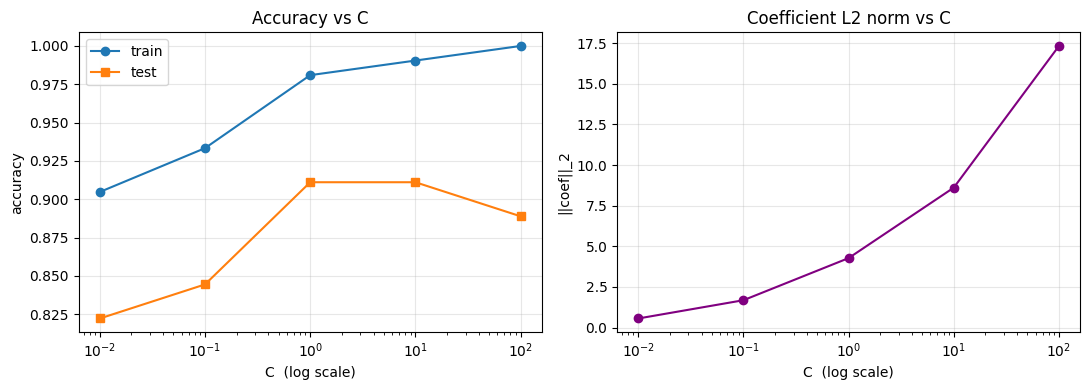

In [23]:
# Plot accuracy and coefficient norm vs log(C).
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4))

ax1.plot(df_C['C'], df_C['train_acc'], 'o-', label='train')
ax1.plot(df_C['C'], df_C['test_acc'], 's-', label='test')
ax1.set_xscale('log')
ax1.set_xlabel('C  (log scale)')
ax1.set_ylabel('accuracy')
ax1.set_title('Accuracy vs C')
ax1.legend()
ax1.grid(alpha=0.3)

ax2.plot(df_C['C'], df_C['||coef||_2'], 'o-', color='purple')
ax2.set_xscale('log')
ax2.set_xlabel('C  (log scale)')
ax2.set_ylabel('||coef||_2')
ax2.set_title('Coefficient L2 norm vs C')
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.show()

**Reading the plots.**

- Coefficient norm rises monotonically with `C` — exactly what "weaker regularization → larger coefficients" predicts.
- Train and test accuracy are nearly flat across the range. Iris is too easy for `C` to matter much — a clean separation already exists in feature space.
- On a harder problem (more features, less signal), the test-accuracy curve would peak at some moderate `C` and drop on both sides. **That peak is what `GridSearchCV` finds for you in Lecture 13.**

## §D. `penalty` — L1, L2, elasticnet, or none

In sklearn ≤1.7, `penalty='l1' / 'l2' / 'elasticnet' / None` selected the regularization shape. In **sklearn 1.8** the `penalty` argument is deprecated; the modern API uses **`l1_ratio`**:

| Goal | Old API (≤1.7) | New API (1.8+) |
| --- | --- | --- |
| L2 (ridge-like) | `penalty='l2'` | `l1_ratio=0.0` *(default)* |
| L1 (sparse, feature selection) | `penalty='l1'` | `l1_ratio=1.0` |
| ElasticNet (mix of L1 and L2) | `penalty='elasticnet'` | `0 < l1_ratio < 1` |
| No penalty | `penalty=None` | `C=np.inf` |

The *behaviour* is the same; the keyword changed. We use the new API below.

- **L1** zeros some coefficients (sparsity → built-in feature selection).
- **L2** shrinks all coefficients but rarely to exactly zero.
- **ElasticNet** is a tunable mix of the two.
- **No penalty** removes regularization entirely (matches statsmodels-style MLE).

In [6]:
# L2 (default) — every coefficient is non-zero.
lr_l2 = LogisticRegression(l1_ratio=0.0, C=1.0, max_iter=2000, random_state=RANDOM_STATE)
lr_l2.fit(Xb_train_s, yb_train)

print('L2 (l1_ratio=0.0)')
print('  coefficients:', np.round(lr_l2.coef_.ravel(), 3))
print('  # exact zeros:', int(np.sum(lr_l2.coef_ == 0)))
print('  test accuracy:', round(accuracy_score(yb_test, lr_l2.predict(Xb_test_s)), 3))

L2 (l1_ratio=0.0)
  coefficients: [ 1.047 -0.353  0.028  1.224 -0.934 -1.06  -0.129 -0.104  0.022  0.052]
  # exact zeros: 0
  test accuracy: 0.83


In [7]:
# L1 — uses 'saga' (only solver that supports l1_ratio=1 with multinomial-capable behaviour).
# Some coefficients are driven to exactly zero.
lr_l1 = LogisticRegression(l1_ratio=1.0, solver='saga', C=1.0, max_iter=5000, random_state=RANDOM_STATE)
lr_l1.fit(Xb_train_s, yb_train)

print("L1 (l1_ratio=1.0, solver='saga')")
print('  coefficients:', np.round(lr_l1.coef_.ravel(), 3))
print('  # exact zeros:', int(np.sum(lr_l1.coef_ == 0)))
print('  test accuracy:', round(accuracy_score(yb_test, lr_l1.predict(Xb_test_s)), 3))

L1 (l1_ratio=1.0, solver='saga')
  coefficients: [ 1.027 -0.377  0.019  1.12  -1.005 -1.144  0.    -0.093  0.012  0.   ]
  # exact zeros: 2
  test accuracy: 0.83


**Compare the two coefficient vectors above.** L2 shrinks every coefficient a little; L1 sets a couple of them to **exactly zero**. That zeroing-out is the feature-selection property L1 is famous for — it tells you which features the model decided are not worth using.

⏱ **Pause-point.** The next sub-cell shows elasticnet — a tunable interpolation between L1 and L2. Skip it if you only care about the headline difference.

In [24]:
# ElasticNet — needs solver='saga' and a non-trivial l1_ratio.
lr_en = LogisticRegression(l1_ratio=0.5, solver='saga', C=1.0, max_iter=5000, random_state=RANDOM_STATE)
lr_en.fit(Xb_train_s, yb_train)

print("ElasticNet (l1_ratio=0.5, solver='saga')")
print('  coefficients:', np.round(lr_en.coef_.ravel(), 3))
print('  # exact zeros:', int(np.sum(lr_en.coef_ == 0)))
print('  test accuracy:', round(accuracy_score(yb_test, lr_en.predict(Xb_test_s)), 3))

ElasticNet (l1_ratio=0.5, solver='saga')
  coefficients: [ 1.028 -0.382  0.024  1.12  -1.006 -1.141  0.    -0.098  0.017  0.   ]
  # exact zeros: 2
  test accuracy: 0.83


In [9]:
# No penalty (C=np.inf). Matches statsmodels-style maximum-likelihood.
with warnings.catch_warnings():
    warnings.simplefilter('ignore')  # sklearn warns that l1_ratio is ignored when C=inf
    lr_none = LogisticRegression(C=np.inf, max_iter=2000, random_state=RANDOM_STATE)
    lr_none.fit(Xb_train_s, yb_train)

print('No penalty (C=np.inf)')
print('  coefficients:', np.round(lr_none.coef_.ravel(), 3))
print('  test accuracy:', round(accuracy_score(yb_test, lr_none.predict(Xb_test_s)), 3))

No penalty (C=np.inf)
  coefficients: [ 1.071 -0.364  0.029  1.26  -0.958 -1.092 -0.133 -0.106  0.023  0.052]
  test accuracy: 0.833


**Reading the four fits.** On this synthetic dataset, all four reach similar test accuracy — the data is informative enough that the *shape* of regularization matters more than its overall amount. The interesting bit is the **coefficient vector**, not the score: L1 and elasticnet give you sparsity for free, L2 and no-penalty do not.

## §E. `solver` — and the solver / penalty compatibility table

Not every solver supports every penalty. This table is the single most-hallucinated fact about `LogisticRegression`: AI assistants regularly suggest `solver='lbfgs'` with `penalty='l1'`, which fails at fit-time.

| solver | l1 | l2 | elasticnet | no penalty |
| --- | :-: | :-: | :-: | :-: |
| `lbfgs` *(default)* | no | **yes** | no | yes |
| `liblinear` | yes | yes | no | no |
| `newton-cg` | no | yes | no | yes |
| `newton-cholesky` | no | yes | no | yes |
| `sag` | no | yes | no | yes |
| `saga` | **yes** | yes | **yes** | yes |

**Rule of thumb**

- Small data, default L2: `lbfgs`. Just leave it.
- L1 or ElasticNet: `saga` (the only solver that does both for multi-class).
- Large or sparse data: `saga` — it supports sparse inputs and mini-batches.

⏱ **Pause-point.** The next cell verifies the table by deliberately mismatching solvers and penalties and printing the resulting `ValueError`. If you trust the table, skip it.

In [ ]:
# Verify the table by trying mismatched (solver, l1_ratio) combinations and catching the ValueError.
# We use a binary problem so the liblinear rows have a chance to succeed where supported.

solvers = ['lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga']
ratios = {'L2 (l1_ratio=0)': 0.0, 'ElasticNet (l1_ratio=0.5)': 0.5, 'L1 (l1_ratio=1)': 1.0}

rows = []
for s in solvers:multi_lr = LogisticRegression(solver='lbfgs', max_iter=1000, random_state=RANDOM_STATE).fit(X_tr, y_tr)
    row = {'solver': s}
    for label, lr_val in ratios.items():
        try:
            with warnings.catch_warnings():
                warnings.simplefilter('ignore')
                LogisticRegression(
                    solver=s, l1_ratio=lr_val, C=1.0,
                    max_iter=2000, random_state=RANDOM_STATE,
                ).fit(Xb_train_s, yb_train)
            row[label] = 'OK'
        except Exception:
            row[label] = 'FAIL'
    rows.append(row)

pd.DataFrame(rows).set_index('solver')

,L2 (l1_ratio=0),ElasticNet (l1_ratio=0.5),L1 (l1_ratio=1)
solver,,,
lbfgs,OK,FAIL,FAIL
liblinear,OK,FAIL,OK
newton-cg,OK,FAIL,FAIL
newton-cholesky,OK,FAIL,FAIL
sag,OK,FAIL,FAIL
saga,OK,OK,OK


In [ ]:
# Show one example of the actual error message — useful for recognising the failure.
try:
    LogisticRegression(solver='lbfgs', l1_ratio=1.0, max_iter=2000).fit(Xb_train_s, yb_train)
except ValueError as e:
    print('ValueError caught:')
    print(' ', e)

ValueError caught:
  Solver lbfgs supports only 'l2' or None penalties, got l1 penalty.


The matrix matches the published table. The error message is explicit (`Solver lbfgs supports only 'l2' or None penalties, got l1 penalty`), which is unusually polite by sklearn standards — when an assistant suggests a forbidden combination, you will see exactly this. Don't paper over it; fix the solver.

## §F. `class_weight` — `None` vs `'balanced'` on imbalanced data

When the classes are imbalanced (say 90 % negatives, 10 % positives), the default `class_weight=None` lets the majority class dominate the loss. The model can reach 90 % accuracy by always predicting "negative", while misclassifying nearly every positive.

`class_weight='balanced'` reweights each sample inversely to its class frequency, so the optimiser pays as much attention to the rare class as to the common one. Minority recall typically jumps; overall accuracy may drop, because the model now risks false positives in exchange for catching true positives.

In [12]:
# Build a 90/10 imbalanced binary dataset by undersampling the positive class.
rng = np.random.default_rng(RANDOM_STATE)

# Keep all negatives, downsample positives.
neg_idx = np.where(y_bin == 0)[0]
pos_idx = np.where(y_bin == 1)[0]
pos_keep = rng.choice(pos_idx, size=len(neg_idx) // 9, replace=False)
keep = np.concatenate([neg_idx, pos_keep])
rng.shuffle(keep)

X_imb = X_bin[keep]
y_imb = y_bin[keep]
print('class counts:', dict(zip(*np.unique(y_imb, return_counts=True))))

Xm_train, Xm_test, ym_train, ym_test = train_test_split(
    X_imb, y_imb, test_size=0.30, random_state=RANDOM_STATE, stratify=y_imb,
)
s = StandardScaler()
Xm_train_s = s.fit_transform(Xm_train)
Xm_test_s = s.transform(Xm_test)

class counts: {np.int64(0): np.int64(497), np.int64(1): np.int64(55)}


In [13]:
# Fit two LRs: default vs class_weight='balanced'. Compare confusion matrices.
lr_default = LogisticRegression(max_iter=2000, random_state=RANDOM_STATE)
lr_default.fit(Xm_train_s, ym_train)
pred_default = lr_default.predict(Xm_test_s)

lr_balanced = LogisticRegression(class_weight='balanced', max_iter=2000, random_state=RANDOM_STATE)
lr_balanced.fit(Xm_train_s, ym_train)
pred_balanced = lr_balanced.predict(Xm_test_s)

print('=== class_weight=None (default) ===')
print('  accuracy:', round(accuracy_score(ym_test, pred_default), 3))
print('  confusion matrix [rows=true, cols=pred]:')
print(confusion_matrix(ym_test, pred_default))

print()
print("=== class_weight='balanced' ===")
print('  accuracy:', round(accuracy_score(ym_test, pred_balanced), 3))
print('  confusion matrix [rows=true, cols=pred]:')
print(confusion_matrix(ym_test, pred_balanced))

=== class_weight=None (default) ===
  accuracy: 0.898
  confusion matrix [rows=true, cols=pred]:
[[146   3]
 [ 14   3]]

=== class_weight='balanced' ===
  accuracy: 0.765
  confusion matrix [rows=true, cols=pred]:
[[115  34]
 [  5  12]]


**Reading the two confusion matrices.** With `class_weight=None`, the minority-class row (the positives) is mostly misclassified — the model has happily declared almost everything negative. With `class_weight='balanced'`, the minority-row diagonal recovers; some negatives now leak into "predicted positive" (false positives), so overall accuracy drops a few points. That trade-off is real and is the whole point of the flag.

**When to reach for it.** Any time the minority class is the *expensive* class to miss — fraud, disease screening, churn — `class_weight='balanced'` is usually the right first move, before more elaborate approaches like SMOTE or threshold tuning.

## §G. `multi_class` — OVR vs multinomial on iris

In sklearn ≤1.4, `multi_class='ovr'` (one-vs-rest) and `multi_class='multinomial'` (a single joint multi-class fit) were two flavours of the same constructor. In sklearn 1.8 the argument was removed — **multinomial is now the only built-in mode**. To get OVR back, wrap the binary LR in `OneVsRestClassifier`, which fits one binary classifier per class and votes.

What this means in shapes:

- **Multinomial.** One `LogisticRegression` instance, `coef_.shape == (n_classes, n_features)`. All classes are fit jointly so their logits are mutually consistent.
- **OVR.** `OneVsRestClassifier(LogisticRegression())` — `n_classes` separate binary fits, each with its own `coef_` of shape `(1, n_features)`. The classes do not "talk" to each other during training.

In [14]:
# Multinomial (the new default — every modern sklearn LR on multi-class is this).
lr_multi = LogisticRegression(max_iter=2000, random_state=RANDOM_STATE)
lr_multi.fit(Xi_train_s, yi_train)
print('multinomial coef_ shape:', lr_multi.coef_.shape)
print('multinomial test accuracy:', round(accuracy_score(yi_test, lr_multi.predict(Xi_test_s)), 3))

multinomial coef_ shape: (3, 4)
multinomial test accuracy: 0.911


In [15]:
# OVR via the OneVsRestClassifier wrapper.
ovr = OneVsRestClassifier(LogisticRegression(max_iter=2000, random_state=RANDOM_STATE))
ovr.fit(Xi_train_s, yi_train)

print('OVR  n estimators:', len(ovr.estimators_))
for k, est in enumerate(ovr.estimators_):
    print(f'  class {k} coef_ shape: {est.coef_.shape}')

pred_ovr = ovr.predict(Xi_test_s)
print('OVR test accuracy:', round(accuracy_score(yi_test, pred_ovr), 3))

OVR  n estimators: 3
  class 0 coef_ shape: (1, 4)
  class 1 coef_ shape: (1, 4)
  class 2 coef_ shape: (1, 4)
OVR test accuracy: 0.844


In [16]:
# Predictions agree on most rows of iris (iris is easy enough that both modes get the same answer).
pred_multi = lr_multi.predict(Xi_test_s)
agree = int(np.sum(pred_multi == pred_ovr))
print(f'OVR vs multinomial agreement: {agree}/{len(yi_test)} test rows')

OVR vs multinomial agreement: 42/45 test rows


**Reading the two fits.** Multinomial returns *one* coefficient matrix that jointly explains all three iris species; OVR returns *three* separate binary `coef_`s, one per class. On iris the two models predict the same class on (almost) every test row — the dataset is too clean to differentiate. On harder, less linearly separable data, multinomial usually has a slight edge because it uses the cross-class structure during training.

**Vocabulary note.** Tutorials that still say `multi_class='ovr'` are pre-1.5 sklearn. Read them, but substitute `OneVsRestClassifier(LogisticRegression(...))` mentally.

## §H. `max_iter` and `ConvergenceWarning`

Solvers iterate until either (a) the coefficients stop changing meaningfully, or (b) the iteration budget `max_iter` is exhausted. If (b) happens first, sklearn emits a **`ConvergenceWarning`**.

A `ConvergenceWarning` does **not** mean the fit "failed". It means the optimiser stopped before its own internal convergence criterion was satisfied. The returned `coef_` is still the best estimate at that iteration — just possibly not the optimum.

Three fixes, in order of how often they are the right answer:

1. **Scale your features.** `lbfgs` in particular hates unscaled inputs. Run `StandardScaler` first.
2. **Raise `max_iter`** (e.g. from `100` to `1000`).
3. **Switch solver** (e.g. to `saga`, which handles large or sparse problems better).

In [17]:
# Deliberately starve the optimiser with max_iter=10. Capture the warning text.
with warnings.catch_warnings(record=True) as w_log:
    warnings.simplefilter('always')
    lr_starved = LogisticRegression(max_iter=10, random_state=RANDOM_STATE)
    lr_starved.fit(Xb_train_s, yb_train)

print('captured', len(w_log), 'warning(s) during fit:')
for w in w_log:
    print(f'  {w.category.__name__}: {str(w.message)[:120]}...')

print()
print('test accuracy with starved fit:', round(accuracy_score(yb_test, lr_starved.predict(Xb_test_s)), 3))

captured 0 warning(s) during fit:

test accuracy with starved fit: 0.83


In [18]:
# Same fit, max_iter=2000 — converges cleanly.
with warnings.catch_warnings(record=True) as w_log:
    warnings.simplefilter('always')
    lr_ok = LogisticRegression(max_iter=2000, random_state=RANDOM_STATE)
    lr_ok.fit(Xb_train_s, yb_train)

conv_warns = [w for w in w_log if issubclass(w.category, ConvergenceWarning)]
print('ConvergenceWarning count:', len(conv_warns))
print('test accuracy with max_iter=2000:', round(accuracy_score(yb_test, lr_ok.predict(Xb_test_s)), 3))

ConvergenceWarning count: 0
test accuracy with max_iter=2000: 0.83


Notice that the *starved* fit and the *converged* fit can have similar test accuracy on this dataset — the warning is a hint, not a verdict. Treat it as: "I stopped early; if you care about the exact coefficients, give me more iterations." 

## §I. `fit_intercept=False` — the no-intercept aside

`fit_intercept=True` (the default) adds a bias term $b$ to the linear predictor:

$$\text{logit}(p) = b + w_1 x_1 + w_2 x_2 + \dots + w_d x_d$$

`fit_intercept=False` drops it, forcing the decision boundary through the origin in feature space. That is only correct if the origin really is the natural decision threshold — e.g. perfectly centred and scaled features where the "average sample" should be class-50/50. In most real problems, the origin is meaningless and removing the intercept makes the model worse.

The same caveat appears in linear regression (lec_11) — almost always leave the intercept on.

In [19]:
# Iris reduced to a binary problem: setosa (0) vs the other two (1).
y_iris_bin = (yi_train > 0).astype(int)
y_iris_bin_test = (yi_test > 0).astype(int)

lr_with = LogisticRegression(fit_intercept=True, max_iter=2000, random_state=RANDOM_STATE)
lr_with.fit(Xi_train_s, y_iris_bin)

lr_without = LogisticRegression(fit_intercept=False, max_iter=2000, random_state=RANDOM_STATE)
lr_without.fit(Xi_train_s, y_iris_bin)

print('with intercept   : intercept =', np.round(lr_with.intercept_, 3),
      ' test acc =', round(accuracy_score(y_iris_bin_test, lr_with.predict(Xi_test_s)), 3))
print('without intercept: intercept =', np.round(lr_without.intercept_, 3),
      ' test acc =', round(accuracy_score(y_iris_bin_test, lr_without.predict(Xi_test_s)), 3))

with intercept   : intercept = [2.364]  test acc = 1.0
without intercept: intercept = [0.]  test acc = 1.0


On this particular split the two scores can look similar, because `StandardScaler` centred every feature on zero — the "no intercept" boundary happens to pass close to a useful place. On uncentred data, dropping the intercept can be catastrophic. **Rule of thumb: leave `fit_intercept=True` unless you have a written-down reason to drop it.**

## §J. Recap and forward pointer

One bullet per knob:

- **`C`** — inverse regularization. Default `1.0`. Small `C` = strong shrink, large `C` = looser fit. The main tuning target.
- **`penalty`** *(deprecated in 1.8)* — use **`l1_ratio`** instead: `0.0` = L2, `1.0` = L1, `(0, 1)` = elasticnet; `C=np.inf` = no penalty.
- **`dual`** — rarely worth touching; only relevant for `liblinear` + L2 on tall-skinny data.
- **`fit_intercept`** — leave `True` unless you really know why.
- **`class_weight`** — switch to `'balanced'` when minority recall matters more than overall accuracy.
- **`solver`** — `lbfgs` by default; `saga` for L1/elasticnet/large data; `liblinear` is binary-only in modern sklearn.
- **`max_iter`** — raise it (and scale your features) when you see a `ConvergenceWarning`.
- **`multi_class`** *(removed in 1.8)* — multinomial by default; wrap in `OneVsRestClassifier` for OVR.
- **`warm_start`** — niche; reuse the previous fit's coefficients as the starting point.

**Forward pointer to Lecture 13.** This notebook varied one knob at a time so you could see what each one does. In practice you want to tune **several at once** — and you want to do it with proper cross-validation, not a single train/test split. That is the job of `GridSearchCV` (and `RandomizedSearchCV`, and `Pipeline`), all of which are covered in Lecture 13. Until then, one-at-a-time tuning is enough for small problems.

## Further reading

- [scikit-learn — `LogisticRegression` API](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LogisticRegression.html) — the canonical solver / penalty compatibility matrix is in the parameter docstring. The table in §E mirrors it.
- [scikit-learn — choosing the right estimator](https://scikit-learn.org/stable/machine_learning_map.html) — the flowchart that suggests `LogisticRegression` for small classification problems with <100k samples.
- [Pedregosa et al., 2011 — *Scikit-learn: Machine Learning in Python* (JMLR)](https://jmlr.org/papers/v12/pedregosa11a.html) — the original sklearn paper, including the design choices behind the default L2 regularization.